#final_dynamic_comparison.py

In [ ]:
pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.5 MB/s eta 0:00:00


In [ ]:
# Сравнение методов в динамической задаче ATSP.
# Для каждого метода выводится пошаговый лог, который сохраняется в отдельную папку.
import os
import networkx as nx
import osmnx as ox
import json
import zipfile
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import csv

# импорты динамических агентов
from dynamic_rl_agents import (
    DynamicPolicyGradientAgent,
    DynamicEnhancedPolicyGradientAgent,
    DynamicImprovedDQNAgent,
    DynamicImprovedDoubleDQNAgent
)

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

Устройство: cpu


In [ ]:
def unzip_all(archives, extract_to):
    for archive in archives:
        if not os.path.exists(archive):
            print(f"Архив {archive} не найден, пропускаем.")
            continue
        with zipfile.ZipFile(archive, 'r') as zf:
            zf.extractall(extract_to)
        print(f"Распакован {archive} в {extract_to}")

def ensure_data_available():
    # Архивы, которые уже содержат папку внутри
    data_archives = ["raw_data.zip"]
    # Архивы, которые не содержат внутренней папки – создаём папку и извлекаем туда
    model_archives = [
        "time_matrices.zip",
        "dynamic_attention_stepwise.zip",            # обученная Attention
        "DynamicPolicyGradient.zip",                 # RL агенты
        "DynamicEnhancedPolicyGradient.zip",
        "DynamicImprovedDQN.zip",
        "DynamicImprovedDoubleDQN.zip",
        "distance_matrices.zip"
    ]

    for archive in data_archives:
        if os.path.exists(archive):
            print(f"Распаковываем {archive} в текущую папку")
            unzip_all([archive], extract_to=".")
        else:
            print(f"Архив {archive} не найден, пропускаем.")

    for archive in model_archives:
        if os.path.exists(archive):
            folder_name = archive.replace('.zip', '')
            os.makedirs(folder_name, exist_ok=True)
            print(f"Распаковываем {archive} в {folder_name}/")
            unzip_all([archive], extract_to=folder_name)
        else:
            print(f"Архив {archive} не найден, пропускаем.")

ensure_data_available()

Распаковываем raw_data.zip в текущую папку
Распакован raw_data.zip в .
Распаковываем time_matrices.zip в time_matrices/
Распакован time_matrices.zip в time_matrices
Распаковываем dynamic_attention_stepwise.zip в dynamic_attention_stepwise/
Распакован dynamic_attention_stepwise.zip в dynamic_attention_stepwise
Распаковываем DynamicPolicyGradient.zip в DynamicPolicyGradient/
Распакован DynamicPolicyGradient.zip в DynamicPolicyGradient
Распаковываем DynamicEnhancedPolicyGradient.zip в DynamicEnhancedPolicyGradient/
Распакован DynamicEnhancedPolicyGradient.zip в DynamicEnhancedPolicyGradient
Распаковываем DynamicImprovedDQN.zip в DynamicImprovedDQN/
Распакован DynamicImprovedDQN.zip в DynamicImprovedDQN
Распаковываем DynamicImprovedDoubleDQN.zip в DynamicImprovedDoubleDQN/
Распакован DynamicImprovedDoubleDQN.zip в DynamicImprovedDoubleDQN
Распаковываем distance_matrices.zip в distance_matrices/
Распакован distance_matrices.zip в distance_matrices


In [ ]:
# 1. Загрузка данных
# Матрицы времени
scenario_names = ["Без_шума", "Пробки", "Блокировки+Пробки", "Умеренные_условия"]
time_matrices = {}
for scenario in scenario_names:
    fname = os.path.join("time_matrices", f"time_matrix_{scenario}.npy")
    if not os.path.exists(fname):
        raise FileNotFoundError(f"Отсутствует файл матрицы времени: {fname}")
    time_matrices[scenario] = np.load(fname)
    print(f"Матрица времени '{scenario}' загружена, размер: {time_matrices[scenario].shape}")

# Матрицы расстояний
distance_matrices = {}
for scenario in scenario_names:
    fname = os.path.join("distance_matrices", f"distance_matrix_{scenario}.npy")
    if not os.path.exists(fname):
        raise FileNotFoundError(f"Отсутствует файл матрицы расстояний: {fname}")
    distance_matrices[scenario] = np.load(fname)
    print(f"Матрица расстояний '{scenario}' загружена, размер: {distance_matrices[scenario].shape}")

n_nodes = time_matrices[scenario_names[0]].shape[0]
print(f"Количество складов: {n_nodes}")

# Информация о складах (только для названий)
with open("raw_data/warehouses_rc_rfc_coordinates.json", "r", encoding="utf-8") as f:
    warehouses = json.load(f)
warehouses_df = pd.DataFrame(warehouses)

Матрица времени 'Без_шума' загружена, размер: (12, 12)
Матрица времени 'Пробки' загружена, размер: (12, 12)
Матрица времени 'Блокировки+Пробки' загружена, размер: (12, 12)
Матрица времени 'Умеренные_условия' загружена, размер: (12, 12)
Матрица расстояний 'Без_шума' загружена, размер: (12, 12)
Матрица расстояний 'Пробки' загружена, размер: (12, 12)
Матрица расстояний 'Блокировки+Пробки' загружена, размер: (12, 12)
Матрица расстояний 'Умеренные_условия' загружена, размер: (12, 12)
Количество складов: 12


In [ ]:
# 2. Временной профиль и среда
def scenario_for_hour(hour):
    if 23 <= hour or hour < 6:   return "Без_шума"
    elif 6 <= hour < 8:          return "Умеренные_условия"
    elif 8 <= hour < 11:         return "Пробки"
    elif 11 <= hour < 17:        return "Умеренные_условия"
    elif 17 <= hour < 20:        return "Блокировки+Пробки"
    elif 20 <= hour < 21:        return "Пробки"
    else:                        return "Умеренные_условия"

class DynamicATSP:
    """Динамическая среда для тестирования с подробным логом и точными расстояниями."""
    def __init__(self, time_matrices, distance_matrices, n_nodes, start_time=6.0):
        self.time_matrices = time_matrices
        self.distance_matrices = distance_matrices
        self.n = n_nodes
        self.start_time = start_time
        self.current_time = start_time
        self.current_node = 0
        self.visited = [False] * n_nodes
        self.visited[0] = True
        self.route = [0]
        self.total_time_h = 0.0
        self.total_distance_km = 0.0
        self.log = []          # список шагов с подробностями

    def _current_matrix(self):
        hour = int(self.current_time)
        scenario = scenario_for_hour(hour)
        return self.time_matrices[scenario]

    # Вспомогательный метод для получения текущей матрицы расстояний
    def _current_distance_matrix(self):
        hour = int(self.current_time)
        scenario = scenario_for_hour(hour)
        return self.distance_matrices[scenario]

    def step(self, action):
        if self.visited[action]:
            raise ValueError("Уже посещён")
        mat = self._current_matrix()
        t = mat[self.current_node, action]
        if np.isinf(t):
            raise ValueError("Путь недостижим")

        # Точное расстояние из матрицы расстояний (метры -> км)
        dist_mat = self._current_distance_matrix()
        dist_km = dist_mat[self.current_node, action] / 1000.0

        scenario = scenario_for_hour(int(self.current_time))
        self.log.append({
            'from_idx': self.current_node,
            'to_idx': action,
            'from_name': warehouses_df.iloc[self.current_node]['name'],
            'to_name': warehouses_df.iloc[action]['name'],
            'departure_time': self.current_time,
            'travel_h': t,
            'arrival_time': self.current_time + t,
            'distance_km': dist_km,
            'scenario': scenario
        })

        self.total_time_h += t
        self.total_distance_km += dist_km
        self.current_time += t
        self.current_node = action
        self.visited[action] = True
        self.route.append(action)

        done = all(self.visited)
        if done:
            t_ret = mat[self.current_node, 0]
            if np.isinf(t_ret):
                raise ValueError("Возврат недостижим")
            # Точное расстояние возврата
            dist_ret_km = dist_mat[self.current_node, 0] / 1000.0
            self.total_time_h += t_ret
            self.total_distance_km += dist_ret_km
            self.route.append(0)
            self.log.append({
                'from_idx': self.current_node,
                'to_idx': 0,
                'from_name': warehouses_df.iloc[self.current_node]['name'],
                'to_name': warehouses_df.iloc[0]['name'],
                'departure_time': self.current_time,
                'travel_h': t_ret,
                'arrival_time': self.current_time + t_ret,
                'distance_km': dist_ret_km,
                'scenario': scenario_for_hour(int(self.current_time))
            })
        return -t, dist_km, done

    def get_state(self):
        mat = self._current_matrix()
        time_vector = mat[self.current_node, :].copy()
        visited_mask = np.array(self.visited, dtype=np.float32)
        return time_vector, visited_mask, self.current_node

In [ ]:
# 3. Модели
# Вспомогательные классы для Attention
class DynamicAttentionModel(nn.Module):
    """Необученная Attention (жадный выбор)."""
    def __init__(self, n_cities, embed_dim=128, num_heads=8, num_layers=3, ff_dim=512):
        super().__init__()
        self.input_proj = nn.Linear(n_cities, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def encode(self, d):
        return self.encoder(self.input_proj(d))

    def decode_one_step(self, enc_out, current_node, visited_mask):
        batch, n, d = enc_out.shape
        q = enc_out[torch.arange(batch), current_node].unsqueeze(1)
        scores = torch.matmul(q, enc_out.transpose(1, 2)) / (d ** 0.5)
        scores = scores.squeeze(1)
        scores = scores.masked_fill(visited_mask, -1e9)
        probs = F.softmax(scores, dim=-1)
        return torch.argmax(probs, dim=-1), probs

class TrainedAttention(nn.Module):
    """Обученная пошагово Attention."""
    def __init__(self, n_cities, embed_dim=128, num_heads=8, num_layers=3, ff_dim=512):
        super().__init__()
        self.input_proj = nn.Linear(n_cities, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def encode(self, d):
        return self.encoder(self.input_proj(d))

    def forward(self, dist_matrix, visited_mask, current):
        enc_out = self.encode(dist_matrix)
        q = enc_out[:, current:current+1, :]
        scores = torch.matmul(q, enc_out.transpose(1,2)) / (enc_out.size(-1) ** 0.5)
        scores = scores.squeeze(1)
        scores = scores.masked_fill(visited_mask, -1e9)
        probs = F.softmax(scores, dim=-1)
        return torch.argmax(probs, dim=-1).item()

In [ ]:
# 4. Загрузка обученных моделей
def load_trained_attention():
    model = TrainedAttention(n_nodes).to(DEVICE)
    ckpt = "dynamic_attention_stepwise/best_model.pt"
    if not os.path.exists(ckpt):
        ckpt = "dynamic_attention_stepwise/final_model.pt"
    if not os.path.exists(ckpt):
        print("чекпоинт обученной Attention не найден")
        return None
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    return model

def load_untrained_attention():
    model = DynamicAttentionModel(n_nodes).to(DEVICE)
    model.eval()
    return model

def load_rl_agent(agent_name, agent_class, n_nodes, checkpoint_dir="."):
    folder_name = f"Dynamic{agent_name}"
    best_ckpt = os.path.join(checkpoint_dir, folder_name, f"{folder_name}_best.pt")
    final_ckpt = os.path.join(checkpoint_dir, folder_name, f"{folder_name}_final.pt")

    if not os.path.exists(best_ckpt) and not os.path.exists(final_ckpt):
        print(f"Чекпоинт для {agent_name} не найден, пропускаем.")
        return None

    ckpt = best_ckpt if os.path.exists(best_ckpt) else final_ckpt
    try:
        # Загружаем целый объект агента (weights_only=False)
        agent = torch.load(ckpt, map_location=DEVICE, weights_only=False)
        # Переводим внутреннюю нейросеть в eval‑режим (если она есть)
        if hasattr(agent, 'policy_network'):
            agent.policy_network.eval()
        elif hasattr(agent, 'q_network'):
            agent.q_network.eval()
        print(f"{agent_name} загружен из {ckpt}")
        return agent
    except Exception as e:
        print(f"Ошибка загрузки {agent_name}: {e}")
        return None

In [ ]:
# 5. Функция тестирования с логом
def test_model_and_log(model, model_name, model_type, result_dict):
    """
    Тестирует модель в динамической среде, печатает лог,
    сохраняет лог в файл и добавляет время/расстояние в result_dict.
    """
    env = DynamicATSP(time_matrices, distance_matrices, n_nodes, start_time=6.0)
    time_vector, visited_mask, current = env.get_state()
    done = False
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(f"Начало: время 6:00, состояние дороги: {scenario_for_hour(6.0)}")

    while not done:
        if model_type == 'attention':
            full_mat = env._current_matrix()
            max_val = full_mat.max()
            norm_mat = full_mat / max_val if max_val > 0 else full_mat
            d_tensor = torch.tensor(norm_mat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            mask_tensor = torch.tensor(visited_mask, dtype=torch.bool).unsqueeze(0).to(DEVICE)
            action = model(d_tensor, mask_tensor, current)
        elif model_type == 'untrained_attention':
            full_mat = env._current_matrix()
            max_val = full_mat.max()
            norm_mat = full_mat / max_val if max_val > 0 else full_mat
            d_tensor = torch.tensor(norm_mat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            mask_tensor = torch.tensor(visited_mask, dtype=torch.bool).unsqueeze(0).to(DEVICE)
            cur_tensor = torch.tensor([current], dtype=torch.long).to(DEVICE)
            enc = model.encode(d_tensor)
            next_node, _ = model.decode_one_step(enc, cur_tensor, mask_tensor)
            action = next_node.item()
        elif model_type == 'rl':
            action = model.select_action(current, visited_mask, time_vector, greedy=True)
        else:
            raise ValueError(f"Неизвестный тип модели: {model_type}")

        # Выполняем шаг
        _, _, done = env.step(action)

        # Вывод последнего шага
        step = env.log[-1]
        from_name = step['from_name']
        to_name = step['to_name']
        dep_h = int(step['departure_time'])
        dep_m = int((step['departure_time'] - dep_h) * 60)
        arr_h = int(step['arrival_time'])
        arr_m = int((step['arrival_time'] - arr_h) * 60)
        print(f"\nВыбран склад: {to_name}")
        print(f"Добрались. Отправление: {dep_h:02d}:{dep_m:02d}, Прибытие: {arr_h:02d}:{arr_m:02d}")
        print(f"Время в пути: {step['travel_h']:.2f} ч, Реальное расстояние: {step['distance_km']:.2f} км")
        print(f"Состояние дороги: {step['scenario']}")

        if not done:
            time_vector, visited_mask, current = env.get_state()

    total_time = env.total_time_h
    total_dist = env.total_distance_km
    print(f"\nИтого: время {total_time:.2f} ч, расстояние {total_dist:.2f} км")
    result_dict[model_name] = {'time_h': total_time, 'distance_km': total_dist}

    # Сохраняем лог в отдельный файл
    log_dir = os.path.join("dynamic_final_results", "logs")
    os.makedirs(log_dir, exist_ok=True)
    log_file = os.path.join(log_dir, f"{model_name.replace(' ', '_')}.log")
    with open(log_file, "w", encoding="utf-8") as f:
        f.write(f" {model_name} \n")
        for i, s in enumerate(env.log):
            dep_h = int(s['departure_time'])
            dep_m = int((s['departure_time'] - dep_h) * 60)
            arr_h = int(s['arrival_time'])
            arr_m = int((s['arrival_time'] - arr_h) * 60)
            f.write(f"Шаг {i+1}: [{dep_h:02d}:{dep_m:02d}] {s['from_name']} -> {s['to_name']}\n")
            f.write(f"   Время в пути: {s['travel_h']:.2f} ч, Расстояние: {s['distance_km']:.2f} км\n")
            f.write(f"   Состояние дороги: {s['scenario']}\n\n")
        f.write(f" ИТОГО: расстояние {total_dist:.2f} км, время {total_time:.2f} ч \n")
    print(f"Лог сохранён: {log_file}")

In [ ]:
def test_model_and_log(model, model_name, model_type, result_dict):
    """
    Тестирует модель в динамической среде с подробным пошаговым выводом в консоль
    и сохранением лога в файл.

    Проблема "разрыва во времени" была вызвана тем, что на последнем шаге
    env.step() добавлял сразу две записи (последний склад + возврат в депо),
    а выводилась только последняя. Теперь выводятся все записи, добавленные
    на текущем шаге.
    """
    env = DynamicATSP(time_matrices, distance_matrices, n_nodes, start_time=6.0)
    time_vector, visited_mask, current = env.get_state()
    done = False

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(f"Начало: время 6:00, состояние дороги: {scenario_for_hour(6.0)}")

    while not done:
        # Выбор действия в зависимости от типа модели
        if model_type == 'attention':
            full_mat = env._current_matrix()
            max_val = full_mat.max()
            norm_mat = full_mat / max_val if max_val > 0 else full_mat
            d_tensor = torch.tensor(norm_mat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            mask_tensor = torch.tensor(visited_mask, dtype=torch.bool).unsqueeze(0).to(DEVICE)
            action = model(d_tensor, mask_tensor, current)

        elif model_type == 'untrained_attention':
            full_mat = env._current_matrix()
            max_val = full_mat.max()
            norm_mat = full_mat / max_val if max_val > 0 else full_mat
            d_tensor = torch.tensor(norm_mat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            mask_tensor = torch.tensor(visited_mask, dtype=torch.bool).unsqueeze(0).to(DEVICE)
            cur_tensor = torch.tensor([current], dtype=torch.long).to(DEVICE)
            enc = model.encode(d_tensor)
            next_node, _ = model.decode_one_step(enc, cur_tensor, mask_tensor)
            action = next_node.item()

        elif model_type == 'rl':
            # Для RL-агентов используем жадный выбор (greedy=True)
            action = model.select_action(current, visited_mask, time_vector, greedy=True)

        else:
            raise ValueError(f"Неизвестный тип модели: {model_type}")

        # Запоминаем количество записей в логе перед шагом
        len_before = len(env.log)

        # Выполняем шаг в среде
        _, _, done = env.step(action)

        # Выводим все записи, добавленные на этом шаге (обычно 1, на последнем – 2)
        for step in env.log[len_before:]:
            from_name = step['from_name']
            to_name = step['to_name']
            dep_h = int(step['departure_time'])
            dep_m = int((step['departure_time'] - dep_h) * 60)
            arr_h = int(step['arrival_time'])
            arr_m = int((step['arrival_time'] - arr_h) * 60)

            print(f"\nВыбран склад: {to_name}")
            print(f"Добрались. Отправление: {dep_h:02d}:{dep_m:02d}, "
                  f"Прибытие: {arr_h:02d}:{arr_m:02d}")
            print(f"Время в пути: {step['travel_h']:.2f} ч, "
                  f"Реальное расстояние: {step['distance_km']:.2f} км")
            print(f"Состояние дороги: {step['scenario']}")

        # Если маршрут ещё не завершён, получаем следующее состояние
        if not done:
            time_vector, visited_mask, current = env.get_state()

    # Итоговый вывод
    total_time = env.total_time_h
    total_dist = env.total_distance_km
    print(f"\nИтого: время {total_time:.2f} ч, расстояние {total_dist:.2f} км")

    # Сохраняем результаты в словарь
    result_dict[model_name] = {'time_h': total_time, 'distance_km': total_dist}

    # Сохраняем подробный лог в файл
    log_dir = os.path.join("dynamic_final_results", "logs")
    os.makedirs(log_dir, exist_ok=True)
    log_file = os.path.join(log_dir, f"{model_name.replace(' ', '_')}.log")
    with open(log_file, "w", encoding="utf-8") as f:
        f.write(f" {model_name} \n")
        for i, s in enumerate(env.log):
            dep_h = int(s['departure_time'])
            dep_m = int((s['departure_time'] - dep_h) * 60)
            arr_h = int(s['arrival_time'])
            arr_m = int((s['arrival_time'] - arr_h) * 60)
            f.write(f"Шаг {i+1}: [{dep_h:02d}:{dep_m:02d}] "
                    f"{s['from_name']} -> {s['to_name']}\n")
            f.write(f"   Время в пути: {s['travel_h']:.2f} ч, "
                    f"Расстояние: {s['distance_km']:.2f} км\n")
            f.write(f"   Состояние дороги: {s['scenario']}\n\n")
        f.write(f" ИТОГО: расстояние {total_dist:.2f} км, время {total_time:.2f} ч \n")
    print(f"Лог сохранён: {log_file}")

In [ ]:
class GreedySolver:
    """
    Обёртка для жадного алгоритма, совместимая с интерфейсом вызова
    test_model_and_log. Просто выбирает ближайший (по времени) непосещённый склад.
    """
    def __init__(self, n_nodes):
        self.n = n_nodes

    def select_action(self, current, visited_mask, time_vector, greedy=True):
        """
        current (int)           – не используется
        visited_mask (np.array) – 1.0 = посещён
        time_vector (np.array)  – время от текущего узла до всех
        """
        valid = np.where(visited_mask == 0)[0]
        if len(valid) == 0:
            return 0          # fallback (не должно случиться)
        best_j = valid[np.argmin(time_vector[valid])]
        return best_j

In [ ]:
# 6. Запуск всех методов
results = {}
# 6.1 Жадный алгоритм 
print("\nЖадный алгоритм")
greedy_solver = GreedySolver(n_nodes)
test_model_and_log(greedy_solver, "Greedy", "rl", results)

# 6.2 Attention (необученная)
model_att_untrained = load_untrained_attention()
if model_att_untrained:
    test_model_and_log(model_att_untrained, "Attention (необуч.)", "untrained_attention", results)

# 6.3 Attention (обученная)
model_att_trained = load_trained_attention()
if model_att_trained:
    test_model_and_log(model_att_trained, "Attention (обуч.)", "attention", results)

# 6.4 RL агенты
rl_configs = {
    "PolicyGradient": (DynamicPolicyGradientAgent, "rl"),
    "EnhancedPolicyGradient": (DynamicEnhancedPolicyGradientAgent, "rl"),
    "ImprovedDQN": (DynamicImprovedDQNAgent, "rl"),
    "ImprovedDoubleDQN": (DynamicImprovedDoubleDQNAgent, "rl"),
}

for agent_name, (agent_cls, agent_type) in rl_configs.items():
    agent = load_rl_agent(agent_name, agent_cls, n_nodes)
    if agent is not None:
        test_model_and_log(agent, agent_name, agent_type, results)


Жадный алгоритм

  Greedy
Начало: время 6:00, состояние дороги: Умеренные_условия

Выбран склад: Новая_Рига_РФЦ
Добрались. Отправление: 06:00, Прибытие: 06:27
Время в пути: 0.46 ч, Реальное расстояние: 17.53 км
Состояние дороги: Умеренные_условия

Выбран склад: Радумля_РФЦ
Добрались. Отправление: 06:27, Прибытие: 07:39
Время в пути: 1.20 ч, Реальное расстояние: 42.60 км
Состояние дороги: Умеренные_условия

Выбран склад: ХОРУГВИНО_РФЦ
Добрались. Отправление: 07:39, Прибытие: 07:51
Время в пути: 0.21 ч, Реальное расстояние: 10.95 км
Состояние дороги: Умеренные_условия

Выбран склад: Пушкино-1
Добрались. Отправление: 07:51, Прибытие: 08:52
Время в пути: 1.01 ч, Реальное расстояние: 70.08 км
Состояние дороги: Умеренные_условия

Выбран склад: Пушкино-2
Добрались. Отправление: 08:52, Прибытие: 08:52
Время в пути: 0.00 ч, Реальное расстояние: 0.00 км
Состояние дороги: Пробки

Выбран склад: Ногинск
Добрались. Отправление: 08:52, Прибытие: 09:50
Время в пути: 0.97 ч, Реальное расстояние: 42.44

In [ ]:
# 7. Итоговая таблица и график
print("\nИтоговая таблица")
print(f"{'Метод':<30} {'Время, ч':>8} {'Расстояние, км':>15}")
print("-"*55)
for method, vals in results.items():
    print(f"{method:<30} {vals['time_h']:>8.2f} {vals['distance_km']:>15.2f}")

# Сохраняем таблицу в CSV и JSON
final_dir = "dynamic_final_results"
os.makedirs(final_dir, exist_ok=True)

with open(os.path.join(final_dir, "final_comparison.json"), "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

with open(os.path.join(final_dir, "final_comparison.csv"), "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Метод", "Время (ч)", "Расстояние (км)"])
    for method, vals in results.items():
        writer.writerow([method, vals["time_h"], vals["distance_km"]])


Итоговая таблица
Метод                          Время, ч  Расстояние, км
-------------------------------------------------------
Greedy                             9.13          439.59
Attention (необуч.)                9.21          463.38
Attention (обуч.)                  9.21          463.38
PolicyGradient                    14.37          792.31
EnhancedPolicyGradient            16.29          880.23
ImprovedDQN                        9.13          439.59
ImprovedDoubleDQN                 10.25          528.75


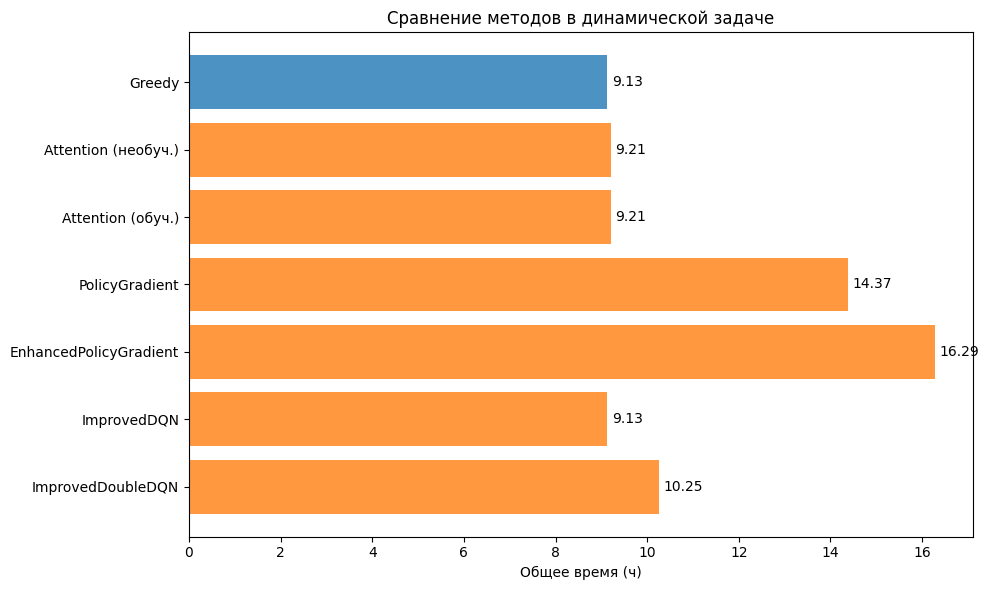

График сохранён: dynamic_final_results/dynamic_comparison.png


In [ ]:
# График сравнения времени
methods = list(results.keys())
times = [results[m]['time_h'] for m in methods]

plt.figure(figsize=(10, 6))
colors = ['#1f77b4' if 'Greedy' in m else '#ff7f0e' for m in methods]
bars = plt.barh(methods, times, color=colors, alpha=0.8)
plt.xlabel('Общее время (ч)')
plt.title('Сравнение методов в динамической задаче')
plt.gca().invert_yaxis()
for bar, v in zip(bars, times):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{v:.2f}', va='center')
plt.tight_layout()
plt.savefig(os.path.join(final_dir, "dynamic_comparison.png"), dpi=150)
plt.show()
print(f"График сохранён: {os.path.join(final_dir, 'dynamic_comparison.png')}")

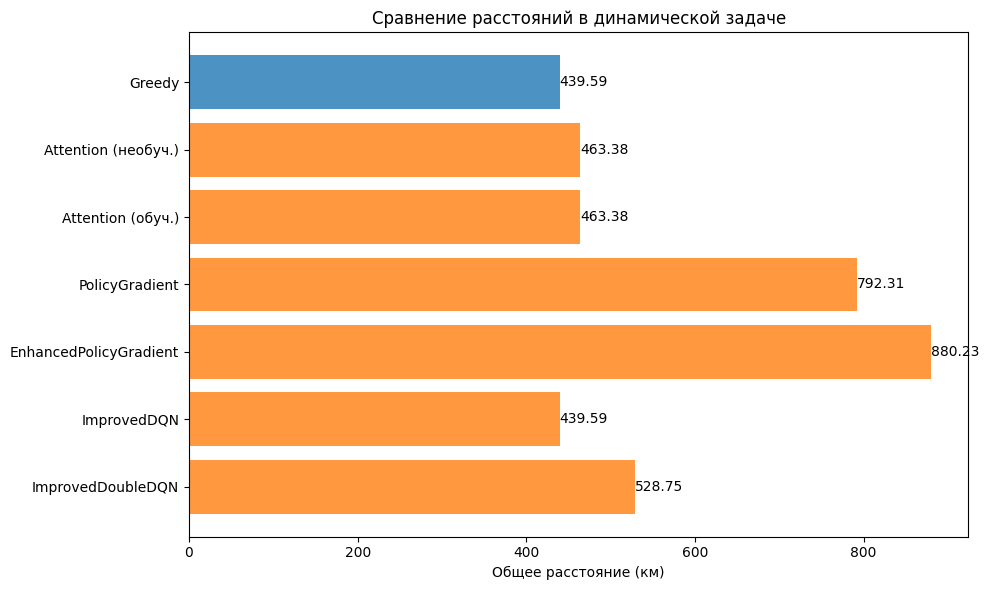

График сохранён: dynamic_final_results/dynamic_comparison_distance.png


In [ ]:
# График сравнения расстояния
methods = list(results.keys())
distances = [results[m]['distance_km'] for m in methods]

plt.figure(figsize=(10, 6))
colors = ['#1f77b4' if 'Greedy' in m else '#ff7f0e' for m in methods]
bars = plt.barh(methods, distances, color=colors, alpha=0.8)
plt.xlabel('Общее расстояние (км)')
plt.title('Сравнение расстояний в динамической задаче')
plt.gca().invert_yaxis()
for bar, v in zip(bars, distances):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{v:.2f}', va='center')
plt.tight_layout()
plt.savefig(os.path.join(final_dir, "dynamic_comparison_distance.png"), dpi=150)
plt.show()
print(f"График сохранён: {os.path.join(final_dir, 'dynamic_comparison_distance.png')}")


Строим маршрут для: ImprovedDQN


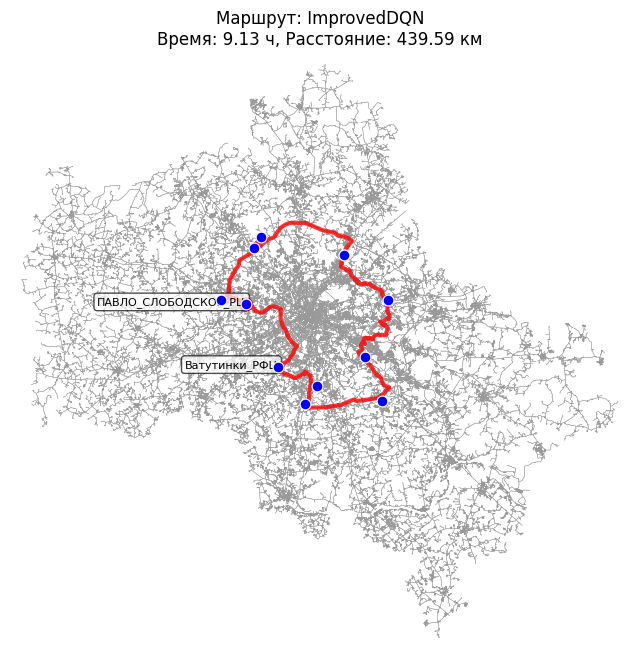

Карта маршрута сохранена: dynamic_final_results/route_ImprovedDQN.png


In [ ]:
# 9. Визуализация маршрута ImprovedDQN на карте дорог

visualize_method = "ImprovedDQN"

if not os.path.exists("noise_graphs"):
    if os.path.exists("noise_graphs.zip"):
        unzip_all(["noise_graphs.zip"], ".")
        print("noise_graphs.zip распакован")
    else:
        raise FileNotFoundError("Для визуализации требуется noise_graphs.zip")

graph_files = {
    "Без_шума": "noise_graphs/graph_Без_шума.graphml",
    "Пробки": "noise_graphs/graph_Пробки.graphml",
    "Блокировки+Пробки": "noise_graphs/graph_Блокировки_Пробки.graphml",
    "Умеренные_условия": "noise_graphs/graph_Умеренные_условия.graphml"
}

scenario_graphs = {}
for scenario, fpath in graph_files.items():
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"Файл графа не найден: {fpath}")
    scenario_graphs[scenario] = ox.load_graphml(fpath)
    for u, v, key, data in scenario_graphs[scenario].edges(keys=True, data=True):
        data['travel_time'] = float(data.get('travel_time',
            data['length'] / (float(data.get('speed_kph', 30)) * 1000 / 3600)))
        data['length'] = float(data['length'])

# Загружаем склады и их узлы (тот же порядок, что и при построении матриц)
with open("raw_data/warehouses_rc_rfc_coordinates.json", "r", encoding="utf-8") as f:
    warehouses = json.load(f)

graph_base = scenario_graphs["Без_шума"]
warehouse_nodes = []
for lat, lon in zip([w['latitude'] for w in warehouses], [w['longitude'] for w in warehouses]):
    node = ox.distance.nearest_nodes(graph_base, lon, lat)
    warehouse_nodes.append(node)
idx_to_name = {i: w['name'] for i, w in enumerate(warehouses)}

# Проверяем, что для выбранного метода есть лог
log_file = os.path.join("dynamic_final_results", "logs", f"{visualize_method.replace(' ', '_')}.log")
if not os.path.exists(log_file):
    print(f"Лог для {visualize_method} не найден: {log_file}. Визуализация пропущена.")
else:
    print(f"\nСтроим маршрут для: {visualize_method}")
    # Парсим лог
    route_segments = []
    with open(log_file, "r", encoding="utf-8") as f:
        lines = f.readlines()
    current_from = None
    current_to = None
    current_dep = None
    for line in lines:
        if line.startswith("Шаг"):
            parts = line.split("]")
            time_str = parts[0].split("[")[1].strip()
            rest = parts[1].strip()
            from_to = rest.split("->")
            from_name = from_to[0].strip()
            to_name = from_to[1].strip()
            dep_h, dep_m = map(int, time_str.split(":"))
            dep_time = dep_h + dep_m / 60.0
            from_idx = next(i for i, w in enumerate(warehouses) if w['name'] == from_name)
            to_idx = next(i for i, w in enumerate(warehouses) if w['name'] == to_name)
            current_from = from_idx
            current_to = to_idx
            current_dep = dep_time
        elif line.startswith("   Состояние дороги:"):
            scenario = line.split(":")[1].strip()
            route_segments.append({
                'from_idx': current_from,
                'to_idx': current_to,
                'dep_time': current_dep,
                'scenario': scenario
            })

    # Строим полный маршрут из узлов графа
    route_nodes = []
    for seg in route_segments:
        from_node = warehouse_nodes[seg['from_idx']]
        to_node = warehouse_nodes[seg['to_idx']]
        graph = scenario_graphs[seg['scenario']]
        try:
            path = nx.shortest_path(graph, from_node, to_node, weight='travel_time')
        except nx.NetworkXNoPath:
            print(f"   Нет пути между {idx_to_name[seg['from_idx']]} и {idx_to_name[seg['to_idx']]}")
            continue
        if route_nodes and route_nodes[-1] == path[0]:
            route_nodes.extend(path[1:])
        else:
            route_nodes.extend(path)

    # Убираем дубликаты подряд
    clean_route = [route_nodes[0]]
    for node in route_nodes[1:]:
        if node != clean_route[-1]:
            clean_route.append(node)
    route_nodes = clean_route

    # Отрисовка
    fig, ax = ox.plot_graph(
        graph_base,
        node_size=0, edge_linewidth=0.3, edge_color='#999999',
        bgcolor='white', show=False, close=False
    )
    if len(route_nodes) > 1:
        ox.plot_graph_route(
            graph_base, route_nodes,
            route_linewidth=3, route_color='red', route_alpha=0.8,
            node_size=0, bgcolor='white',
            ax=ax, show=False, close=False
        )
        # Отмечаем склады
        for i, node in enumerate(warehouse_nodes):
            x, y = graph_base.nodes[node]['x'], graph_base.nodes[node]['y']
            ax.scatter(x, y, c='blue', s=60, zorder=5, edgecolors='white', linewidth=0.8)
            if i == 0 or i == len(warehouse_nodes)-1:
                ax.text(x, y, idx_to_name[i], fontsize=8, ha='right', color='black',
                        bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
        # Если метод есть в результатах, выводим итоговые цифры
        time_str = f"{results[visualize_method]['time_h']:.2f}" if visualize_method in results else "?"
        dist_str = f"{results[visualize_method]['distance_km']:.2f}" if visualize_method in results else "?"
        ax.set_title(f"Маршрут: {visualize_method}\nВремя: {time_str} ч, Расстояние: {dist_str} км")
        map_path = os.path.join("dynamic_final_results", f"route_{visualize_method}.png")
        plt.savefig(map_path, dpi=200, bbox_inches='tight')
        plt.show()
        print(f"Карта маршрута сохранена: {map_path}")
    else:
        print("Не удалось построить маршрут: пустой список узлов.")


Худший метод: EnhancedPolicyGradient, время 16.29 ч
Строим маршрут для: EnhancedPolicyGradient


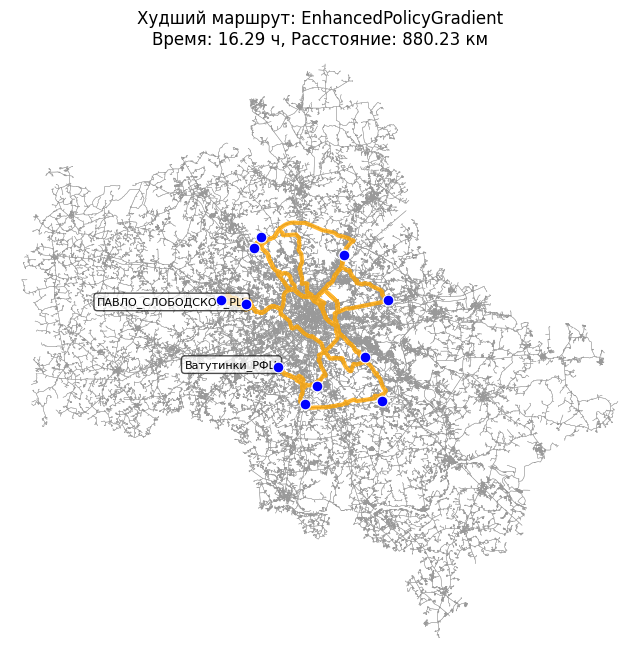

Карта худшего маршрута сохранена: dynamic_final_results/route_worst_EnhancedPolicyGradient.png


In [ ]:
# 10. Визуализация худшего маршрута (максимальное общее время)

if results:
    worst_method = max(results, key=lambda m: results[m]['time_h'])
    print(f"\nХудший метод: {worst_method}, время {results[worst_method]['time_h']:.2f} ч")
else:
    worst_method = None

if worst_method:
    log_file_worst = os.path.join("dynamic_final_results", "logs", f"{worst_method.replace(' ', '_')}.log")
    if os.path.exists(log_file_worst):
        print(f"Строим маршрут для: {worst_method}")
        # Парсинг лога
        route_segments_worst = []
        with open(log_file_worst, "r", encoding="utf-8") as f:
            lines = f.readlines()
        current_from = None
        current_to = None
        current_dep = None
        for line in lines:
            if line.startswith("Шаг"):
                parts = line.split("]")
                time_str = parts[0].split("[")[1].strip()
                rest = parts[1].strip()
                from_to = rest.split("->")
                from_name = from_to[0].strip()
                to_name = from_to[1].strip()
                dep_h, dep_m = map(int, time_str.split(":"))
                dep_time = dep_h + dep_m / 60.0
                from_idx = next(i for i, w in enumerate(warehouses) if w['name'] == from_name)
                to_idx = next(i for i, w in enumerate(warehouses) if w['name'] == to_name)
                current_from = from_idx
                current_to = to_idx
                current_dep = dep_time
            elif line.startswith("   Состояние дороги:"):
                scenario = line.split(":")[1].strip()
                route_segments_worst.append({
                    'from_idx': current_from,
                    'to_idx': current_to,
                    'dep_time': current_dep,
                    'scenario': scenario
                })

        # Построение полного маршрута
        route_nodes_worst = []
        for seg in route_segments_worst:
            from_node = warehouse_nodes[seg['from_idx']]
            to_node = warehouse_nodes[seg['to_idx']]
            graph = scenario_graphs[seg['scenario']]
            try:
                path = nx.shortest_path(graph, from_node, to_node, weight='travel_time')
            except nx.NetworkXNoPath:
                print(f"   Нет пути между {idx_to_name[seg['from_idx']]} и {idx_to_name[seg['to_idx']]}")
                continue
            if route_nodes_worst and route_nodes_worst[-1] == path[0]:
                route_nodes_worst.extend(path[1:])
            else:
                route_nodes_worst.extend(path)

        # Убираем дубликаты
        clean_route_worst = [route_nodes_worst[0]]
        for node in route_nodes_worst[1:]:
            if node != clean_route_worst[-1]:
                clean_route_worst.append(node)
        route_nodes_worst = clean_route_worst

        # Отрисовка
        fig2, ax2 = ox.plot_graph(
            graph_base,
            node_size=0, edge_linewidth=0.3, edge_color='#999999',
            bgcolor='white', show=False, close=False
        )
        if len(route_nodes_worst) > 1:
            ox.plot_graph_route(
                graph_base, route_nodes_worst,
                route_linewidth=3, route_color='orange', route_alpha=0.8,
                node_size=0, bgcolor='white',
                ax=ax2, show=False, close=False
            )
            for i, node in enumerate(warehouse_nodes):
                x, y = graph_base.nodes[node]['x'], graph_base.nodes[node]['y']
                ax2.scatter(x, y, c='blue', s=60, zorder=5, edgecolors='white', linewidth=0.8)
                if i == 0 or i == len(warehouse_nodes)-1:
                    ax2.text(x, y, idx_to_name[i], fontsize=8, ha='right', color='black',
                             bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
            time_str = f"{results[worst_method]['time_h']:.2f}" if worst_method in results else "?"
            dist_str = f"{results[worst_method]['distance_km']:.2f}" if worst_method in results else "?"
            ax2.set_title(f"Худший маршрут: {worst_method}\nВремя: {time_str} ч, Расстояние: {dist_str} км")
            map_path_worst = os.path.join("dynamic_final_results", f"route_worst_{worst_method}.png")
            plt.savefig(map_path_worst, dpi=200, bbox_inches='tight')
            plt.show()
            print(f"Карта худшего маршрута сохранена: {map_path_worst}")
        else:
            print("Не удалось построить маршрут: пустой список узлов.")
    else:
        print(f"Лог для {worst_method} не найден: {log_file_worst}. Визуализация пропущена.")
else:
    print("Нет данных для определения худшего метода.")

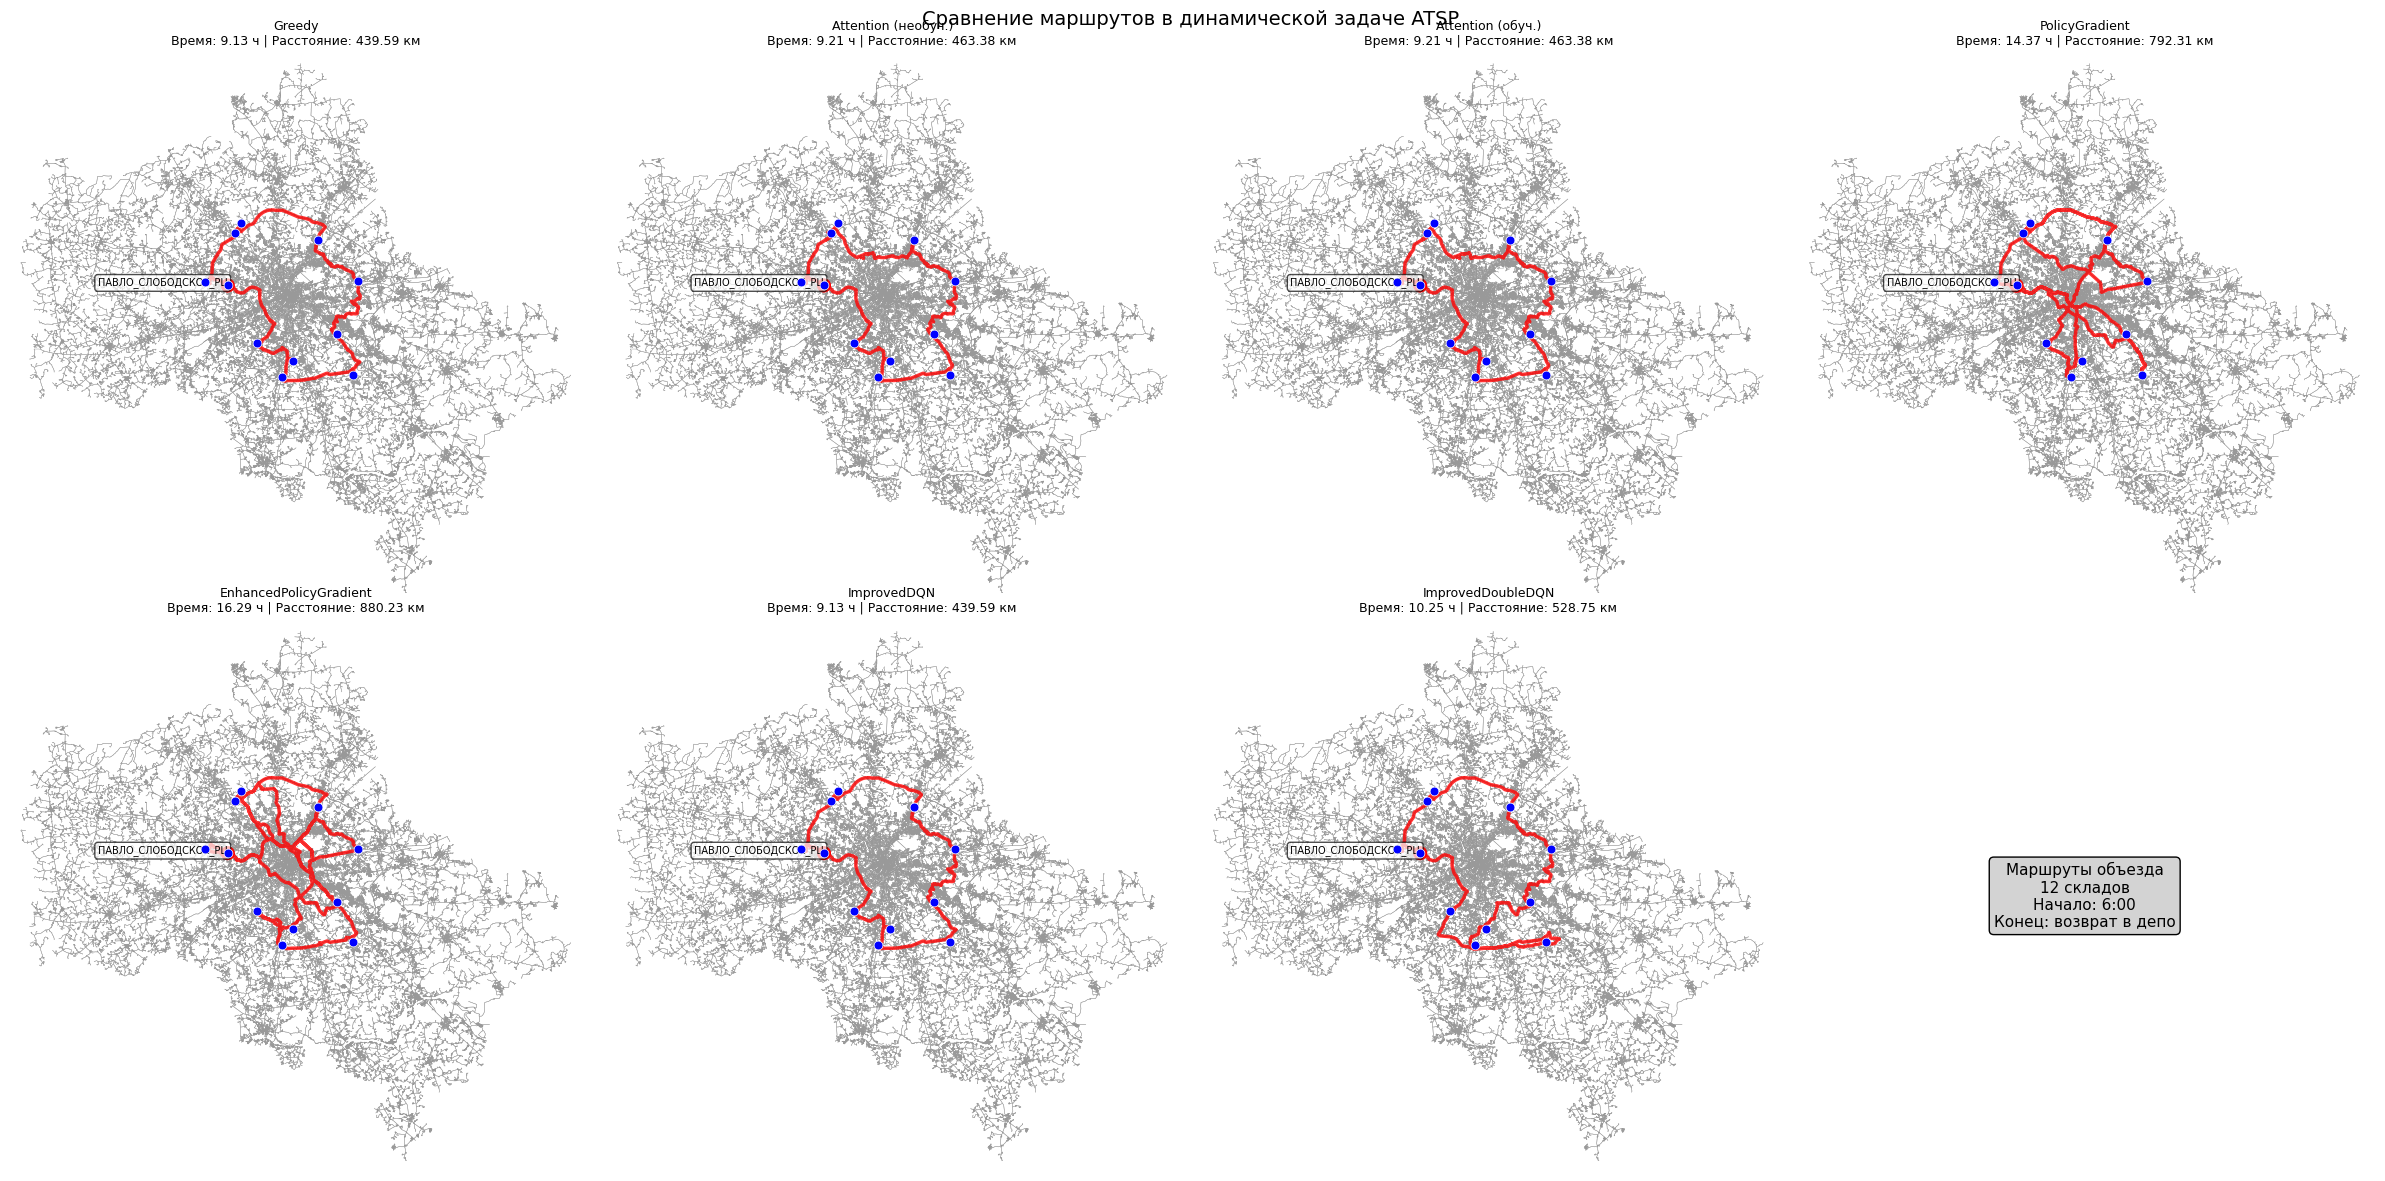

Матрица маршрутов сохранена: dynamic_final_results/all_routes_matrix.png


In [ ]:
# 11. Матрица всех маршрутов (subplots)
# Формируем список методов в нужном порядке
all_methods = [
    "Greedy",
    "Attention (необуч.)",
    "Attention (обуч.)",
    "PolicyGradient",
    "EnhancedPolicyGradient",
    "ImprovedDQN",
    "ImprovedDoubleDQN"
]

# Функция построения маршрута по логу
def build_route_from_log(method_name):
    log_path = os.path.join("dynamic_final_results", "logs", f"{method_name.replace(' ', '_')}.log")
    if not os.path.exists(log_path):
        print(f"Лог {log_path} не найден")
        return None
    # Парсинг (аналогично предыдущим блокам)
    segments = []
    current_from = None
    current_to = None
    current_dep = None
    with open(log_path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    for line in lines:
        if line.startswith("Шаг"):
            parts = line.split("]")
            time_str = parts[0].split("[")[1].strip()
            rest = parts[1].strip()
            from_to = rest.split("->")
            from_name = from_to[0].strip()
            to_name = from_to[1].strip()
            dep_h, dep_m = map(int, time_str.split(":"))
            dep_time = dep_h + dep_m / 60.0
            from_idx = next(i for i, w in enumerate(warehouses) if w['name'] == from_name)
            to_idx = next(i for i, w in enumerate(warehouses) if w['name'] == to_name)
            current_from = from_idx
            current_to = to_idx
            current_dep = dep_time
        elif line.startswith("   Состояние дороги:"):
            scenario = line.split(":")[1].strip()
            segments.append({
                'from_idx': current_from,
                'to_idx': current_to,
                'dep_time': current_dep,
                'scenario': scenario
            })
    if not segments:
        return None
    # Сборка узлов
    route_nodes = []
    for seg in segments:
        from_node = warehouse_nodes[seg['from_idx']]
        to_node = warehouse_nodes[seg['to_idx']]
        graph = scenario_graphs[seg['scenario']]
        try:
            path = nx.shortest_path(graph, from_node, to_node, weight='travel_time')
        except nx.NetworkXNoPath:
            continue
        if route_nodes and route_nodes[-1] == path[0]:
            route_nodes.extend(path[1:])
        else:
            route_nodes.extend(path)
    # Удаление дубликатов
    clean = [route_nodes[0]]
    for n in route_nodes[1:]:
        if n != clean[-1]:
            clean.append(n)
    return clean

# Собираем маршруты для каждого метода
routes = {}
for method in all_methods:
    routes[method] = build_route_from_log(method)

# Создаём сетку 2x4 (8 ячеек, 7 занято)
fig, axes = plt.subplots(2, 4, figsize=(24, 12))  # широкое изображение
axes = axes.flatten()

for idx, method in enumerate(all_methods):
    ax = axes[idx]
    # Рисуем базовый граф (серый)
    ox.plot_graph(graph_base, node_size=0, edge_linewidth=0.3, edge_color='#999999',
                  bgcolor='white', ax=ax, show=False, close=False)
    route = routes.get(method)
    if route and len(route) > 1:
        ox.plot_graph_route(graph_base, route,
                            route_linewidth=2.5, route_color='red', route_alpha=0.8,
                            node_size=0, bgcolor='white', ax=ax, show=False, close=False)
        # Склады (синие точки)
        for i, node in enumerate(warehouse_nodes):
            x, y = graph_base.nodes[node]['x'], graph_base.nodes[node]['y']
            ax.scatter(x, y, c='blue', s=40, zorder=5, edgecolors='white', linewidth=0.5)
            # Подписываем только депо
            if i == 0:
                ax.text(x, y, idx_to_name[i], fontsize=7, ha='right', color='black',
                        bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
        # Заголовок с метриками (если есть)
        t = results[method]['time_h'] if method in results else '?'
        d = results[method]['distance_km'] if method in results else '?'
        ax.set_title(f"{method}\nВремя: {t:.2f} ч | Расстояние: {d:.2f} км", fontsize=9)
    else:
        ax.set_title(f"{method}\nМаршрут не построен", fontsize=9)
    # Убираем оси координат для чистоты
    ax.set_axis_off()

# Последняя (пустая) ячейка — можно оставить пустой или добавить легенду
axes[-1].set_axis_off()
# Опционально текст легенды
axes[-1].text(0.5, 0.5, 'Маршруты объезда\n12 складов\nНачало: 6:00\nКонец: возврат в депо',
              transform=axes[-1].transAxes, ha='center', va='center', fontsize=11,
              bbox=dict(boxstyle='round', facecolor='lightgrey'))

plt.suptitle("Сравнение маршрутов в динамической задаче ATSP", fontsize=14, y=0.98)
plt.tight_layout()
matrix_path = os.path.join("dynamic_final_results", "all_routes_matrix.png")
plt.savefig(matrix_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Матрица маршрутов сохранена: {matrix_path}")

In [ ]:
# 8. Архивация
shutil.make_archive(final_dir, 'zip', final_dir)
print(f"Все результаты сохранены в {final_dir}.zip")

Все результаты сохранены в dynamic_final_results.zip
